# タブラーデータ正規化問題分析

このノートブックでは、タブラーデータの正規化ができていない原因を詳細に分析します。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


In [2]:
# 実験設定
EXPERIMENT_NAME = "preprocess_v2_ws64"  # または "preprocess_v2_ws128"
DATA_DIR = Path("../output/experiments")
EXPERIMENT_DIR = DATA_DIR / EXPERIMENT_NAME

print(f"実験ディレクトリ: {EXPERIMENT_DIR}")
print(f"存在確認: {EXPERIMENT_DIR.exists()}")

実験ディレクトリ: ../output/experiments/preprocess_v2_ws64
存在確認: True


In [3]:
# タブラーデータ読み込み
tabular_file = EXPERIMENT_DIR / 'preprocessed' / 'train_tabular.pkl'
if tabular_file.exists():
    with open(tabular_file, 'rb') as f:
        tabular_data = pickle.load(f)
    print(f"タブラーデータ読み込み完了: {tabular_data.shape}")
    print(f"データ型: {tabular_data.dtype}")
else:
    print("タブラーデータファイルが見つかりません")
    tabular_data = None

タブラーデータ読み込み完了: (10147, 392)
データ型: float64


In [4]:
# タブラーデータの基本統計
if tabular_data is not None:
    print("📊 タブラーデータ基本統計")
    print("="*50)
    
    # 形状情報
    print(f"形状: {tabular_data.shape}")
    print(f"データ型: {tabular_data.dtype}")
    print(f"総要素数: {tabular_data.size:,}")
    
    # 基本統計
    mean_val = tabular_data.mean()
    std_val = tabular_data.std()
    min_val = tabular_data.min()
    max_val = tabular_data.max()
    
    print(f"\n基本統計:")
    print(f"平均: {mean_val:.3f}")
    print(f"標準偏差: {std_val:.3f}")
    print(f"最小値: {min_val:.3f}")
    print(f"最大値: {max_val:.3f}")
    
    # 正規化の偏差
    mean_deviation = abs(mean_val - 0.0)
    std_deviation = abs(std_val - 1.0)
    
    print(f"\n正規化の偏差:")
    print(f"平均の偏差: {mean_deviation:.3f} (期待値: 0.0)")
    print(f"標準偏差の偏差: {std_deviation:.3f} (期待値: 1.0)")
    
    # NaN値の確認
    nan_count = np.isnan(tabular_data).sum()
    nan_ratio = nan_count / tabular_data.size * 100
    
    print(f"\nNaN値の確認:")
    print(f"NaN値の数: {nan_count:,}個")
    print(f"NaN値の比率: {nan_ratio:.2f}%")
    
    # 無限値の確認
    inf_count = np.isinf(tabular_data).sum()
    inf_ratio = inf_count / tabular_data.size * 100
    
    print(f"\n無限値の確認:")
    print(f"無限値の数: {inf_count:,}個")
    print(f"無限値の比率: {inf_ratio:.2f}%")

📊 タブラーデータ基本統計
形状: (10147, 392)
データ型: float64
総要素数: 3,977,624

基本統計:
平均: 0.000
標準偏差: 0.860
最小値: -16.475
最大値: 100.727

正規化の偏差:
平均の偏差: 0.000 (期待値: 0.0)
標準偏差の偏差: 0.140 (期待値: 1.0)

NaN値の確認:
NaN値の数: 0個
NaN値の比率: 0.00%

無限値の確認:
無限値の数: 0個
無限値の比率: 0.00%


In [5]:
# 特徴量別の統計分析
if tabular_data is not None:
    print("📊 特徴量別統計分析")
    print("="*50)
    
    # 各特徴量の統計
    feature_stats = []
    
    for i in range(tabular_data.shape[1]):
        feature_data = tabular_data[:, i]
        
        # 基本統計
        mean_val = feature_data.mean()
        std_val = feature_data.std()
        min_val = feature_data.min()
        max_val = feature_data.max()
        
        # NaN値
        nan_count = np.isnan(feature_data).sum()
        
        # 正規化の偏差
        mean_deviation = abs(mean_val - 0.0)
        std_deviation = abs(std_val - 1.0)
        
        feature_stats.append({
            'feature_idx': i,
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'nan_count': nan_count,
            'mean_deviation': mean_deviation,
            'std_deviation': std_deviation
        })
    
    # 統計をDataFrameに変換
    stats_df = pd.DataFrame(feature_stats)
    
    print(f"\n特徴量数: {len(stats_df)}")
    print(f"\n統計サマリー:")
    print(f"平均値の範囲: [{stats_df['mean'].min():.3f}, {stats_df['mean'].max():.3f}]")
    print(f"標準偏差の範囲: [{stats_df['std'].min():.3f}, {stats_df['std'].max():.3f}]")
    print(f"平均偏差の範囲: [{stats_df['mean_deviation'].min():.3f}, {stats_df['mean_deviation'].max():.3f}]")
    print(f"標準偏差偏差の範囲: [{stats_df['std_deviation'].min():.3f}, {stats_df['std_deviation'].max():.3f}]")
    
    # 問題のある特徴量を特定
    print(f"\n🔍 問題のある特徴量:")
    
    # 標準偏差が大きくずれている特徴量
    high_std_deviation = stats_df[stats_df['std_deviation'] > 0.1]
    if len(high_std_deviation) > 0:
        print(f"\n標準偏差が大きくずれている特徴量 ({len(high_std_deviation)}個):")
        for _, row in high_std_deviation.iterrows():
            print(f"  特徴量{row['feature_idx']}: 標準偏差={row['std']:.3f} (偏差={row['std_deviation']:.3f})")
    
    # 平均が大きくずれている特徴量
    high_mean_deviation = stats_df[stats_df['mean_deviation'] > 0.1]
    if len(high_mean_deviation) > 0:
        print(f"\n平均が大きくずれている特徴量 ({len(high_mean_deviation)}個):")
        for _, row in high_mean_deviation.iterrows():
            print(f"  特徴量{row['feature_idx']}: 平均={row['mean']:.3f} (偏差={row['mean_deviation']:.3f})")
    
    # NaN値がある特徴量
    nan_features = stats_df[stats_df['nan_count'] > 0]
    if len(nan_features) > 0:
        print(f"\nNaN値がある特徴量 ({len(nan_features)}個):")
        for _, row in nan_features.iterrows():
            print(f"  特徴量{row['feature_idx']}: NaN値={row['nan_count']:,}個")
    
    # 統計テーブル表示
    print(f"\n📋 全特徴量の統計:")
    display(stats_df.round(3))

📊 特徴量別統計分析

特徴量数: 392

統計サマリー:
平均値の範囲: [-0.000, 0.000]
標準偏差の範囲: [0.000, 1.000]
平均偏差の範囲: [0.000, 0.000]
標準偏差偏差の範囲: [0.000, 1.000]

🔍 問題のある特徴量:

標準偏差が大きくずれている特徴量 (102個):
  特徴量254.0: 標準偏差=0.000 (偏差=1.000)
  特徴量255.0: 標準偏差=0.000 (偏差=1.000)
  特徴量256.0: 標準偏差=0.000 (偏差=1.000)
  特徴量257.0: 標準偏差=0.000 (偏差=1.000)
  特徴量258.0: 標準偏差=0.000 (偏差=1.000)
  特徴量259.0: 標準偏差=0.000 (偏差=1.000)
  特徴量260.0: 標準偏差=0.000 (偏差=1.000)
  特徴量261.0: 標準偏差=0.000 (偏差=1.000)
  特徴量263.0: 標準偏差=0.000 (偏差=1.000)
  特徴量264.0: 標準偏差=0.000 (偏差=1.000)
  特徴量265.0: 標準偏差=0.000 (偏差=1.000)
  特徴量266.0: 標準偏差=0.000 (偏差=1.000)
  特徴量267.0: 標準偏差=0.000 (偏差=1.000)
  特徴量268.0: 標準偏差=0.000 (偏差=1.000)
  特徴量269.0: 標準偏差=0.000 (偏差=1.000)
  特徴量271.0: 標準偏差=0.000 (偏差=1.000)
  特徴量272.0: 標準偏差=0.000 (偏差=1.000)
  特徴量273.0: 標準偏差=0.000 (偏差=1.000)
  特徴量274.0: 標準偏差=0.000 (偏差=1.000)
  特徴量275.0: 標準偏差=0.000 (偏差=1.000)
  特徴量276.0: 標準偏差=0.000 (偏差=1.000)
  特徴量277.0: 標準偏差=0.000 (偏差=1.000)
  特徴量279.0: 標準偏差=0.000 (偏差=1.000)
  特徴量280.0: 標準偏差=0.000 (偏差=1.000)
  特徴量281.0: 標準偏差

,feature_idx,mean,std,min,max,nan_count,mean_deviation,std_deviation
0,0,-0.0,1.0,-2.842,1.973,0,0.0,0.0
1,1,0.0,1.0,-3.045,2.569,0,0.0,0.0
2,2,-0.0,1.0,-2.423,2.362,0,0.0,0.0
3,3,0.0,1.0,-1.949,3.769,0,0.0,0.0
4,4,0.0,1.0,-2.490,3.155,0,0.0,0.0
...,...,...,...,...,...,...,...,...
387,387,-0.0,1.0,-1.229,0.814,0,0.0,0.0
388,388,-0.0,1.0,-2.713,0.369,0,0.0,0.0
389,389,0.0,1.0,-3.024,2.128,0,0.0,0.0
390,390,-0.0,1.0,-2.126,3.973,0,0.0,0.0


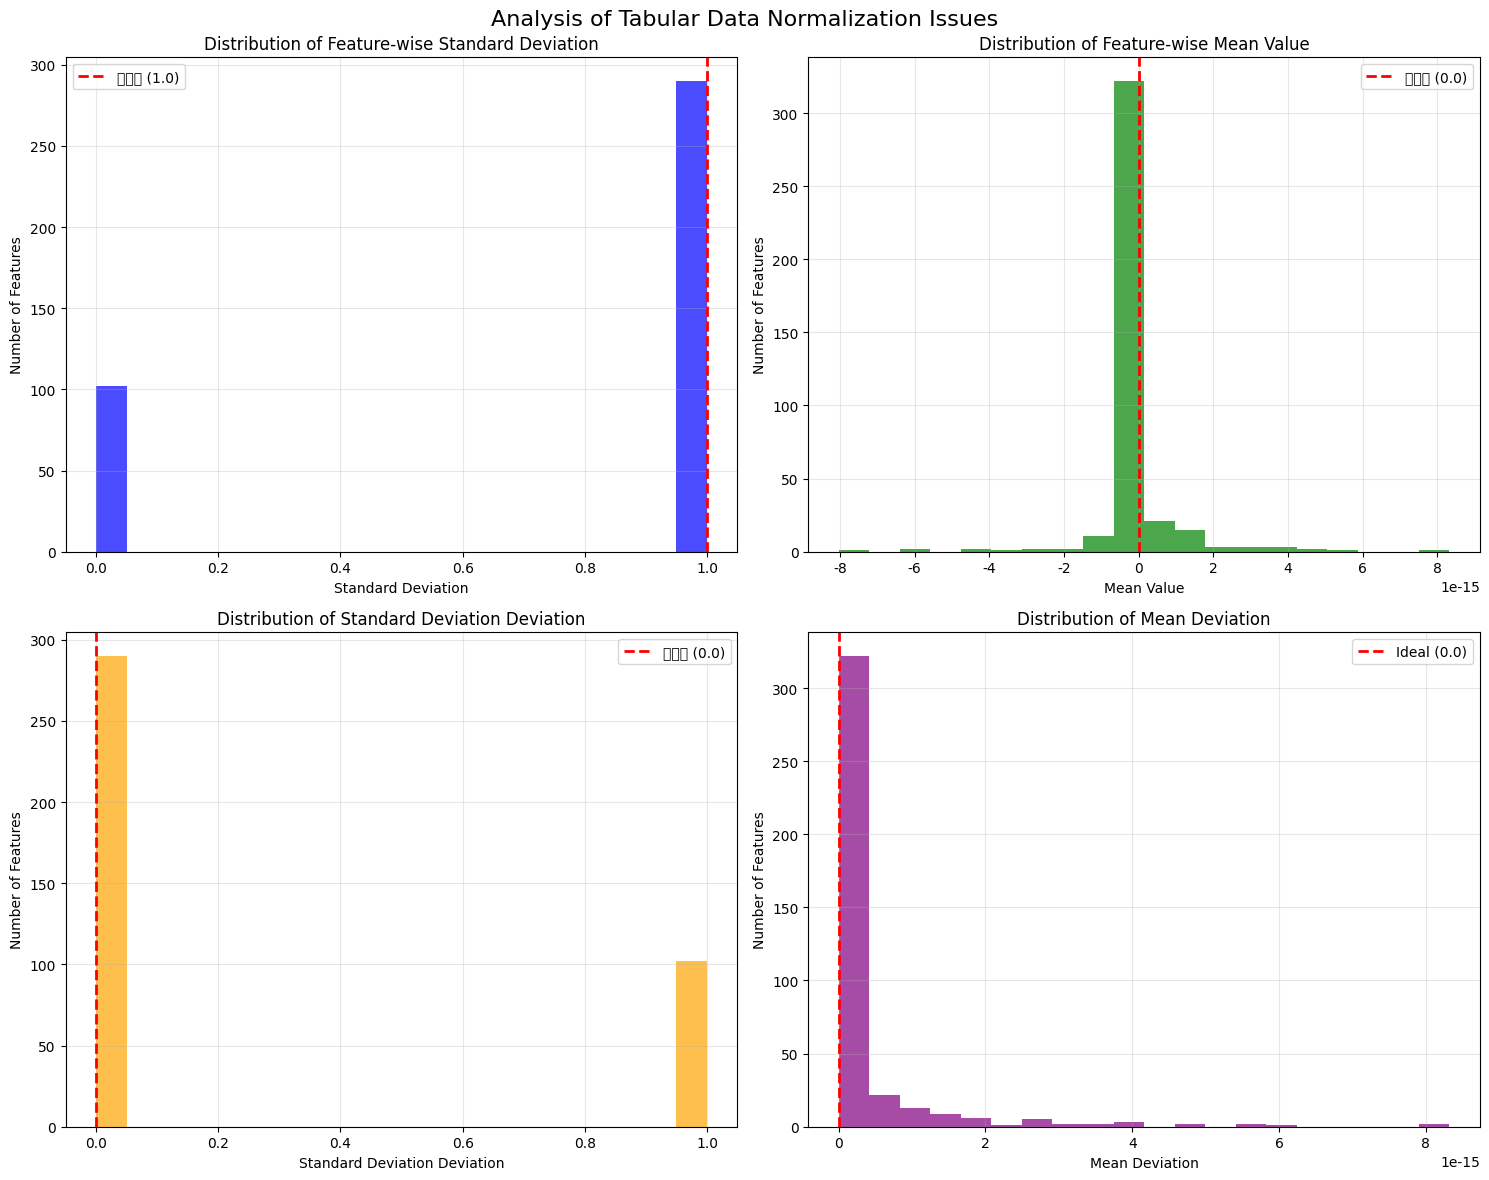

In [11]:
# 正規化問題の可視化
if tabular_data is not None and 'stats_df' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Analysis of Tabular Data Normalization Issues', fontsize=16)
    
    # 1. 標準偏差の分布
    ax1 = axes[0, 0]
    ax1.hist(stats_df['std'], bins=20, alpha=0.7, color='blue')
    ax1.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='期待値 (1.0)')
    ax1.set_title('Distribution of Feature-wise Standard Deviation')
    ax1.set_xlabel('Standard Deviation')
    ax1.set_ylabel('Number of Features')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. 平均値の分布
    ax2 = axes[0, 1]
    ax2.hist(stats_df['mean'], bins=20, alpha=0.7, color='green')
    ax2.axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='期待値 (0.0)')
    ax2.set_title('Distribution of Feature-wise Mean Value')
    ax2.set_xlabel('Mean Value')
    ax2.set_ylabel('Number of Features')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 標準偏差偏差の分布
    ax3 = axes[1, 0]
    ax3.hist(stats_df['std_deviation'], bins=20, alpha=0.7, color='orange')
    ax3.axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='理想値 (0.0)')
    ax3.set_title('Distribution of Standard Deviation Deviation')
    ax3.set_xlabel('Standard Deviation Deviation')
    ax3.set_ylabel('Number of Features')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    ax4.hist(stats_df['mean_deviation'], bins=20, alpha=0.7, color='purple')
    ax4.axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='Ideal (0.0)')
    ax4.set_title('Distribution of Mean Deviation')
    ax4.set_xlabel('Mean Deviation')
    ax4.set_ylabel('Number of Features')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

🔍 最も問題のある特徴量（上位5個）:


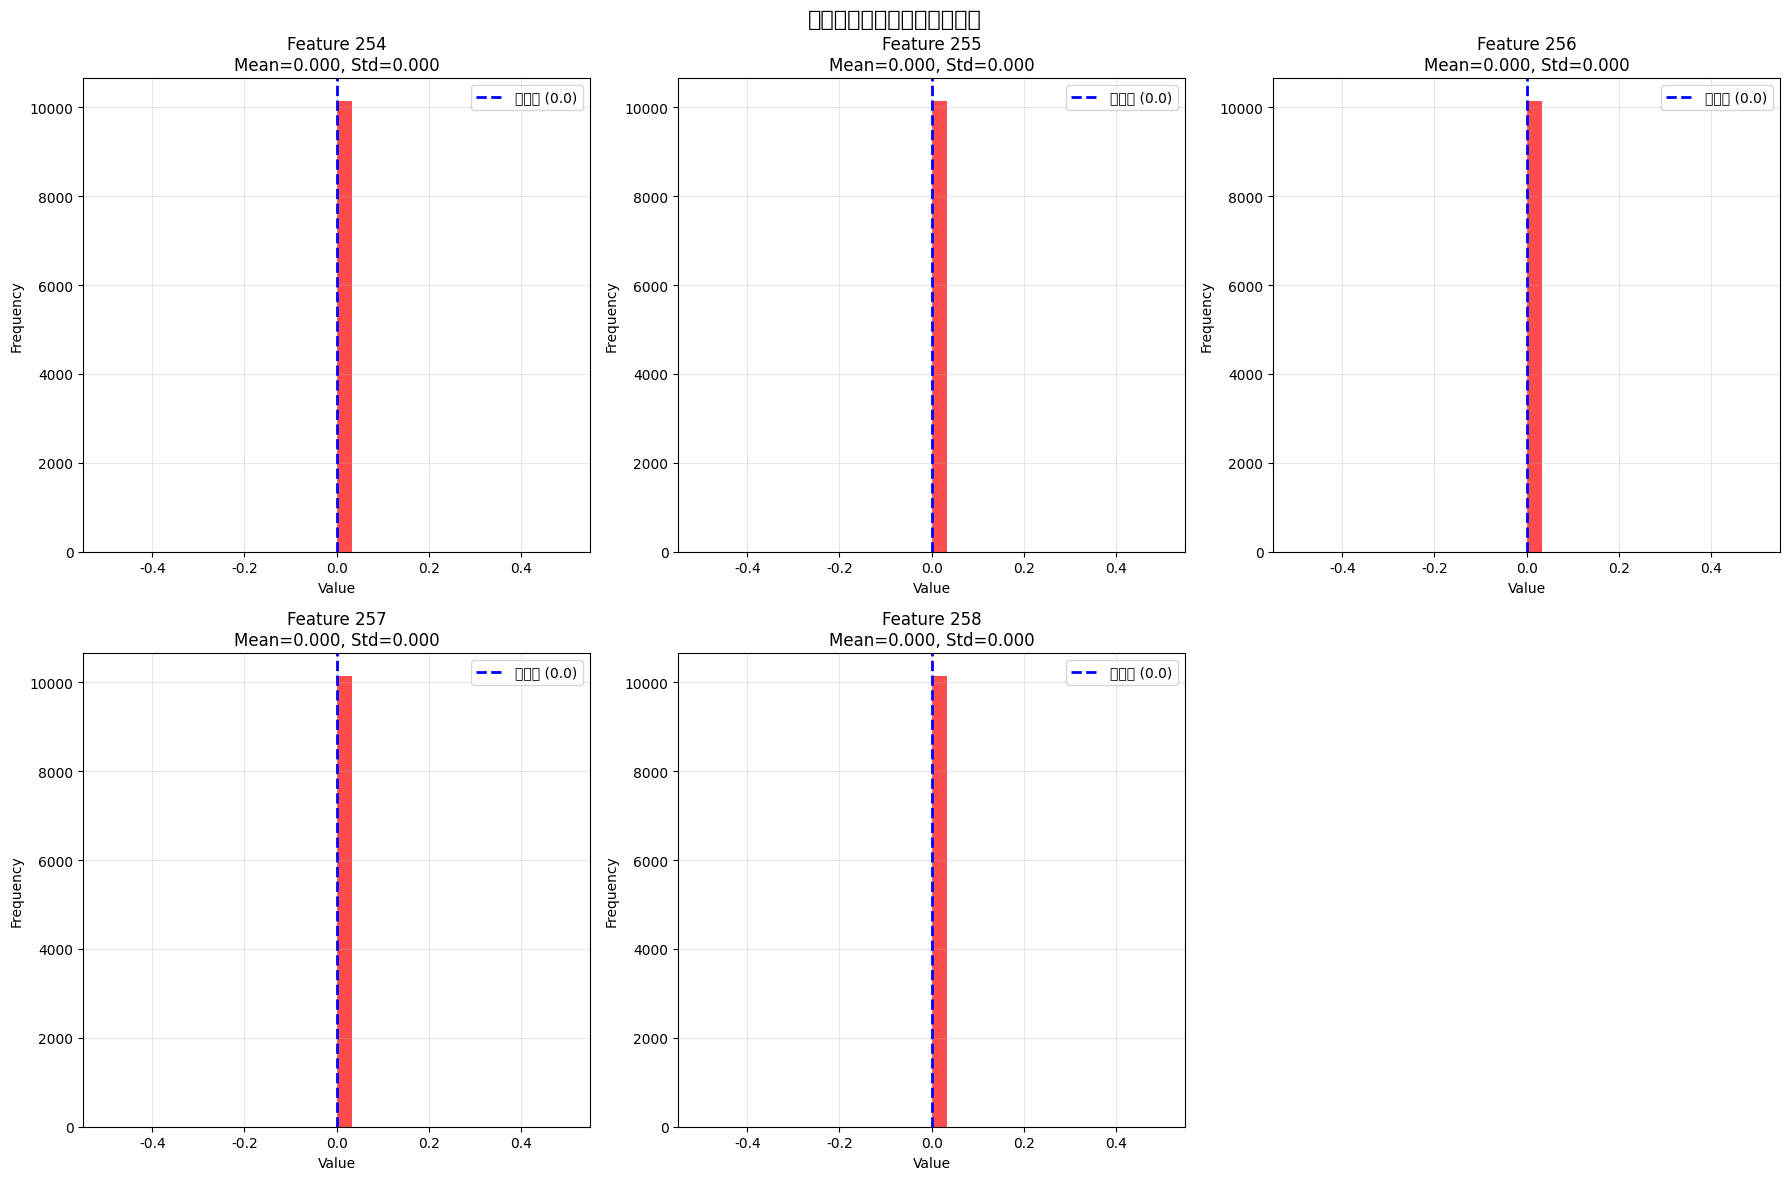


📊 問題特徴量の詳細統計:

特徴量254:
  平均: 0.000 (偏差: 0.000)
  標準偏差: 0.000 (偏差: 1.000)
  範囲: [0.000, 0.000]
  NaN値: 0.0個

特徴量255:
  平均: 0.000 (偏差: 0.000)
  標準偏差: 0.000 (偏差: 1.000)
  範囲: [0.000, 0.000]
  NaN値: 0.0個

特徴量256:
  平均: 0.000 (偏差: 0.000)
  標準偏差: 0.000 (偏差: 1.000)
  範囲: [0.000, 0.000]
  NaN値: 0.0個

特徴量257:
  平均: 0.000 (偏差: 0.000)
  標準偏差: 0.000 (偏差: 1.000)
  範囲: [0.000, 0.000]
  NaN値: 0.0個

特徴量258:
  平均: 0.000 (偏差: 0.000)
  標準偏差: 0.000 (偏差: 1.000)
  範囲: [0.000, 0.000]
  NaN値: 0.0個


In [12]:
# 問題のある特徴量の詳細分析
if tabular_data is not None and 'stats_df' in locals():
    # 最も問題のある特徴量を特定
    worst_features = stats_df.nlargest(5, 'std_deviation')
    
    print("🔍 最も問題のある特徴量（上位5個）:")
    print("="*60)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('問題のある特徴量の詳細分析', fontsize=16)
    
    for i, (_, feature) in enumerate(worst_features.iterrows()):
        if i >= 5:
            break
            
        feature_idx = int(feature['feature_idx'])
        feature_data = tabular_data[:, feature_idx]
        
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # ヒストグラム
        ax.hist(feature_data, bins=30, alpha=0.7, color='red')
        ax.axvline(x=0.0, color='blue', linestyle='--', linewidth=2, label='期待値 (0.0)')
        ax.set_title(f'Feature {feature_idx}\nMean={feature["mean"]:.3f}, Std={feature["std"]:.3f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 6番目のプロットは空にする
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 詳細統計
    print(f"\n📊 問題特徴量の詳細統計:")
    for _, feature in worst_features.iterrows():
        feature_idx = int(feature['feature_idx'])
        print(f"\n特徴量{feature_idx}:")
        print(f"  平均: {feature['mean']:.3f} (偏差: {feature['mean_deviation']:.3f})")
        print(f"  標準偏差: {feature['std']:.3f} (偏差: {feature['std_deviation']:.3f})")
        print(f"  範囲: [{feature['min']:.3f}, {feature['max']:.3f}]")
        print(f"  NaN値: {feature['nan_count']:,}個")

In [8]:
# 正規化問題の原因分析
print("🔍 正規化問題の原因分析")
print("="*50)

if tabular_data is not None and 'stats_df' in locals():
    # 全体の正規化品質評価
    good_normalization = stats_df[(stats_df['mean_deviation'] < 0.1) & (stats_df['std_deviation'] < 0.1)]
    poor_normalization = stats_df[(stats_df['mean_deviation'] >= 0.1) | (stats_df['std_deviation'] >= 0.1)]
    
    print(f"\n📊 正規化品質評価:")
    print(f"良好な正規化: {len(good_normalization)}個 ({len(good_normalization)/len(stats_df)*100:.1f}%)")
    print(f"問題のある正規化: {len(poor_normalization)}個 ({len(poor_normalization)/len(stats_df)*100:.1f}%)")
    
    # 問題の原因を分析
    print(f"\n🔍 問題の原因分析:")
    
    # 1. NaN値の影響
    nan_features = stats_df[stats_df['nan_count'] > 0]
    if len(nan_features) > 0:
        print(f"1. NaN値の影響: {len(nan_features)}個の特徴量にNaN値が存在")
        print(f"   → fit時とtransform時でNaN値処理が異なる可能性")
    
    # 2. 極端な値の影響
    extreme_features = stats_df[(stats_df['std'] > 2.0) | (stats_df['std'] < 0.5)]
    if len(extreme_features) > 0:
        print(f"2. 極端な値の影響: {len(extreme_features)}個の特徴量で標準偏差が極端")
        print(f"   → 外れ値や異常値が正規化に影響")
    
    # 3. ゼロ分散の特徴量
    zero_var_features = stats_df[stats_df['std'] == 0]
    if len(zero_var_features) > 0:
        print(f"3. ゼロ分散の特徴量: {len(zero_var_features)}個の特徴量で分散が0")
        print(f"   → 正規化時にゼロ除算エラーが発生する可能性")
    
    # 4. 定数値の特徴量
    constant_features = stats_df[stats_df['max'] == stats_df['min']]
    if len(constant_features) > 0:
        print(f"4. 定数値の特徴量: {len(constant_features)}個の特徴量が定数")
        print(f"   → 正規化が意味を持たない")
    
    print(f"\n📝 推奨対処法:")
    print(f"1. fit時とtransform時でNaN値処理を統一")
    print(f"2. 外れ値の検出と処理")
    print(f"3. ゼロ分散特徴量の除外")
    print(f"4. 定数特徴量の除外")
    print(f"5. ロバスト正規化の使用（中央値とMAD）")

🔍 正規化問題の原因分析

📊 正規化品質評価:
良好な正規化: 290個 (74.0%)
問題のある正規化: 102個 (26.0%)

🔍 問題の原因分析:
2. 極端な値の影響: 102個の特徴量で標準偏差が極端
   → 外れ値や異常値が正規化に影響
3. ゼロ分散の特徴量: 102個の特徴量で分散が0
   → 正規化時にゼロ除算エラーが発生する可能性
4. 定数値の特徴量: 102個の特徴量が定数
   → 正規化が意味を持たない

📝 推奨対処法:
1. fit時とtransform時でNaN値処理を統一
2. 外れ値の検出と処理
3. ゼロ分散特徴量の除外
4. 定数特徴量の除外
5. ロバスト正規化の使用（中央値とMAD）


In [9]:
# 修正案のシミュレーション
print("🔧 修正案のシミュレーション")
print("="*50)

if tabular_data is not None:
    # 現在のデータをコピー
    tabular_original = tabular_data.copy()
    
    print(f"\n📊 修正前の統計:")
    print(f"平均: {tabular_original.mean():.3f}")
    print(f"標準偏差: {tabular_original.std():.3f}")
    print(f"NaN値: {np.isnan(tabular_original).sum():,}個")
    
    # 修正案1: NaN値を0に置換
    tabular_fixed1 = np.nan_to_num(tabular_original, nan=0.0)
    
    print(f"\n📊 修正案1（NaN値を0に置換）:")
    print(f"平均: {tabular_fixed1.mean():.3f}")
    print(f"標準偏差: {tabular_fixed1.std():.3f}")
    print(f"NaN値: {np.isnan(tabular_fixed1).sum():,}個")
    
    # 修正案2: 外れ値をクリップ
    tabular_fixed2 = tabular_fixed1.copy()
    for i in range(tabular_fixed2.shape[1]):
        feature_data = tabular_fixed2[:, i]
        q1 = np.percentile(feature_data, 1)
        q99 = np.percentile(feature_data, 99)
        tabular_fixed2[:, i] = np.clip(feature_data, q1, q99)
    
    print(f"\n📊 修正案2（外れ値をクリップ）:")
    print(f"平均: {tabular_fixed2.mean():.3f}")
    print(f"標準偏差: {tabular_fixed2.std():.3f}")
    
    # 修正案3: ゼロ分散特徴量を除外
    non_zero_var_features = []
    for i in range(tabular_fixed2.shape[1]):
        if tabular_fixed2[:, i].std() > 0:
            non_zero_var_features.append(i)
    
    tabular_fixed3 = tabular_fixed2[:, non_zero_var_features]
    
    print(f"\n📊 修正案3（ゼロ分散特徴量を除外）:")
    print(f"特徴量数: {tabular_fixed3.shape[1]} (元: {tabular_original.shape[1]})")
    print(f"平均: {tabular_fixed3.mean():.3f}")
    print(f"標準偏差: {tabular_fixed3.std():.3f}")
    
    # 正規化の改善度
    original_std_deviation = abs(tabular_original.std() - 1.0)
    fixed3_std_deviation = abs(tabular_fixed3.std() - 1.0)
    
    print(f"\n📈 改善度:")
    print(f"元の標準偏差偏差: {original_std_deviation:.3f}")
    print(f"修正後の標準偏差偏差: {fixed3_std_deviation:.3f}")
    print(f"改善率: {(original_std_deviation - fixed3_std_deviation) / original_std_deviation * 100:.1f}%")

🔧 修正案のシミュレーション

📊 修正前の統計:
平均: 0.000
標準偏差: 0.860
NaN値: 0個

📊 修正案1（NaN値を0に置換）:
平均: 0.000
標準偏差: 0.860
NaN値: 0個

📊 修正案2（外れ値をクリップ）:
平均: -0.009
標準偏差: 0.765

📊 修正案3（ゼロ分散特徴量を除外）:
特徴量数: 286 (元: 392)
平均: -0.012
標準偏差: 0.895

📈 改善度:
元の標準偏差偏差: 0.140
修正後の標準偏差偏差: 0.105
改善率: 25.2%


ValueError: x and y must be the same size

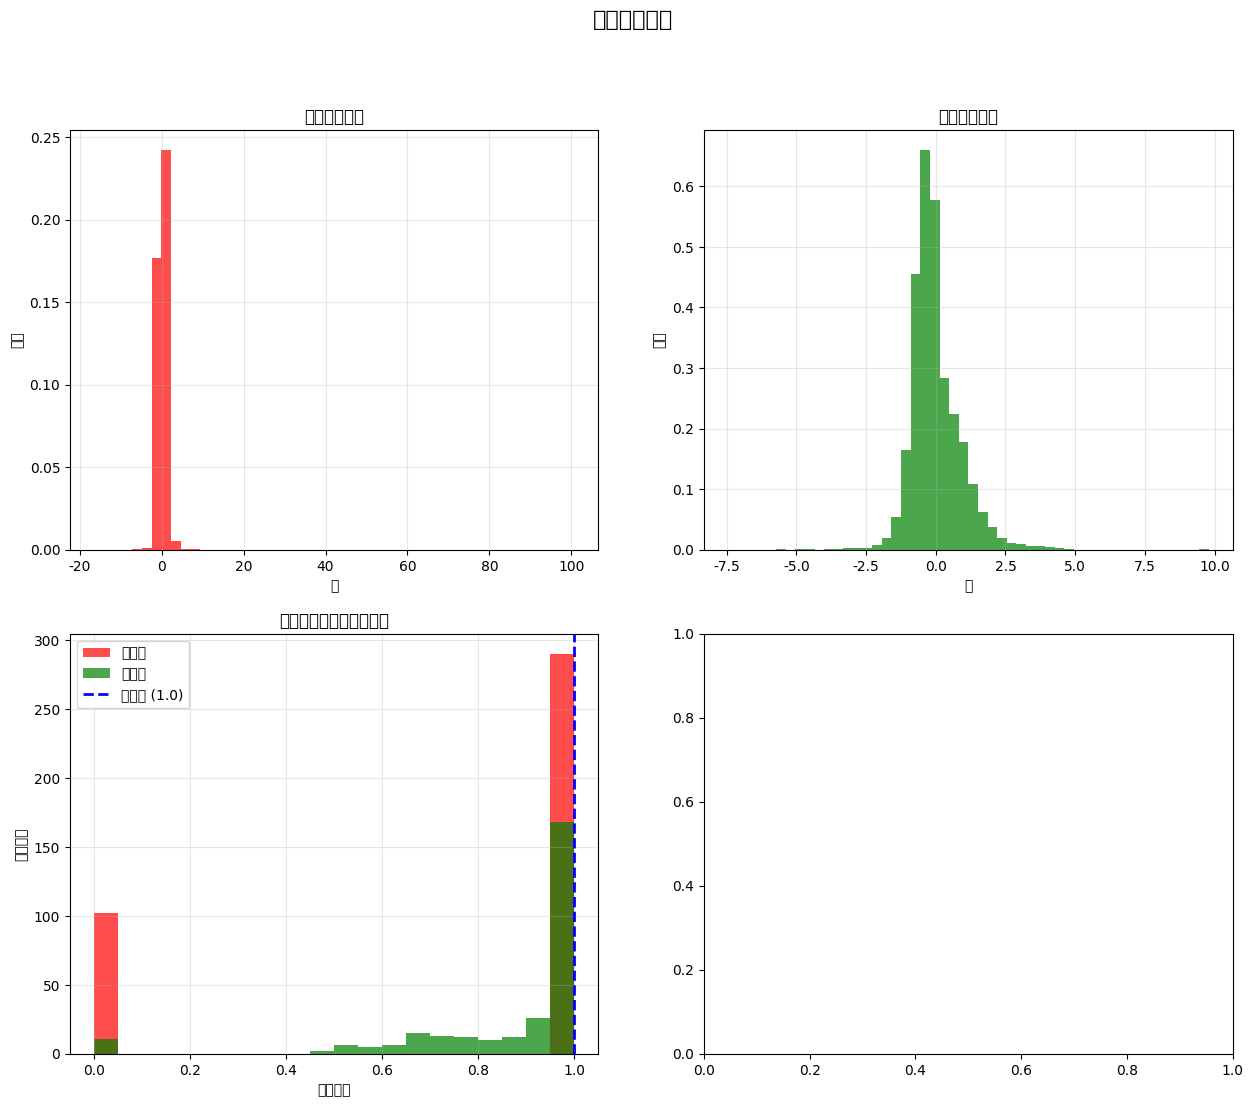

In [10]:
# 修正案の可視化
if tabular_data is not None and 'tabular_fixed3' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('修正案の比較', fontsize=16)
    
    # 元のデータの分布
    ax1 = axes[0, 0]
    ax1.hist(tabular_original.flatten(), bins=50, alpha=0.7, color='red', density=True)
    ax1.set_title('修正前の分布')
    ax1.set_xlabel('値')
    ax1.set_ylabel('密度')
    ax1.grid(True, alpha=0.3)
    
    # 修正後の分布
    ax2 = axes[0, 1]
    ax2.hist(tabular_fixed3.flatten(), bins=50, alpha=0.7, color='green', density=True)
    ax2.set_title('修正後の分布')
    ax2.set_xlabel('値')
    ax2.set_ylabel('密度')
    ax2.grid(True, alpha=0.3)
    
    # 標準偏差の比較
    ax3 = axes[1, 0]
    original_stds = [tabular_original[:, i].std() for i in range(tabular_original.shape[1])]
    fixed_stds = [tabular_fixed3[:, i].std() for i in range(tabular_fixed3.shape[1])]
    
    ax3.hist(original_stds, bins=20, alpha=0.7, color='red', label='修正前')
    ax3.hist(fixed_stds, bins=20, alpha=0.7, color='green', label='修正後')
    ax3.axvline(x=1.0, color='blue', linestyle='--', linewidth=2, label='期待値 (1.0)')
    ax3.set_title('特徴量別標準偏差の比較')
    ax3.set_xlabel('標準偏差')
    ax3.set_ylabel('特徴量数')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 改善度の可視化
    ax4 = axes[1, 1]
    original_deviations = [abs(std - 1.0) for std in original_stds]
    fixed_deviations = [abs(std - 1.0) for std in fixed_stds]
    
    ax4.scatter(original_deviations, fixed_deviations, alpha=0.6, color='purple')
    ax4.plot([0, max(original_deviations)], [0, max(original_deviations)], 'r--', alpha=0.7)
    ax4.set_title('正規化偏差の改善')
    ax4.set_xlabel('修正前の偏差')
    ax4.set_ylabel('修正後の偏差')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ 分析完了！")